In [1]:
!pip install gwpy PyCBC lalsuite lxml


[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [12]:
import pandas as pd
import numpy as np
import gwpy
import matplotlib.pyplot as plt

In [13]:
from gwosc.datasets import event_gps


gps = event_gps('GW190412')
segment = (int(gps)-5, int(gps)+5)


from gwpy.timeseries import TimeSeries
ldata = TimeSeries.fetch_open_data('L1', *segment, verbose=True)
vdata = TimeSeries.fetch_open_data('V1', *segment, verbose=True)
hdata = TimeSeries.fetch_open_data('H1', *segment, verbose=True)

Fetched 1 URLs from gwosc.org for [1239082257 .. 1239082267))
Reading data... [Done]
Fetched 1 URLs from gwosc.org for [1239082257 .. 1239082267))
Reading data... [Done]
Fetched 1 URLs from gwosc.org for [1239082257 .. 1239082267))
Reading data... [Done]


In [14]:
fft = ldata.fft()
print(fft)

FrequencySeries([-1.45894410e-21+0.00000000e+00j,
                 -2.91834926e-21-4.52905657e-23j,
                 -2.91973330e-21-9.06202944e-23j, ...,
                 -2.38723982e-23+4.67871178e-26j,
                 -2.38345362e-23+1.80394058e-26j,
                 -2.38457175e-23+0.00000000e+00j]
                unit: dimensionless,
                f0: 0.0 Hz,
                df: 0.1 Hz,
                epoch: 1239082257.0,
                name: Strain,
                channel: None)


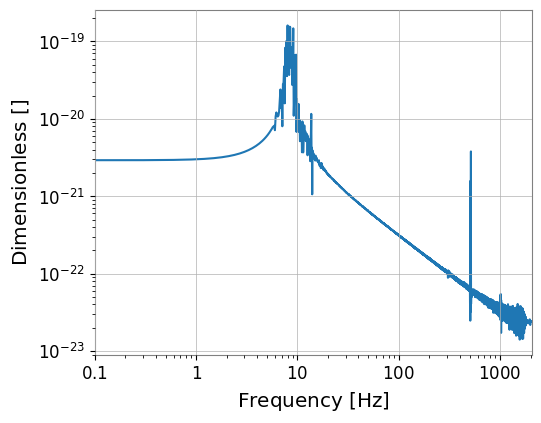

In [15]:
plot = fft.abs().plot(xscale="log", yscale="log")

We need to apply a window function to our time-domain data before transforming as our data is not periodic. 

Hann Function is given by
$w[n]=0.5(1−cos(\frac{2 \pi n}{N-1}))$

In [16]:
import numpy as np

N = ldata.size
n = np.arange(N)

# Hann Window
window = 0.5 * (1 - np.cos(2 * np.pi * n / (N - 1)))

lwin_my = ldata * window

In [17]:
from scipy.signal import get_window
window = get_window('hann', ldata.size)
lwin = ldata * window

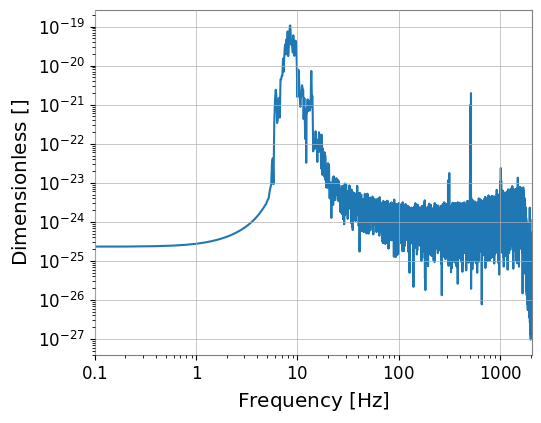

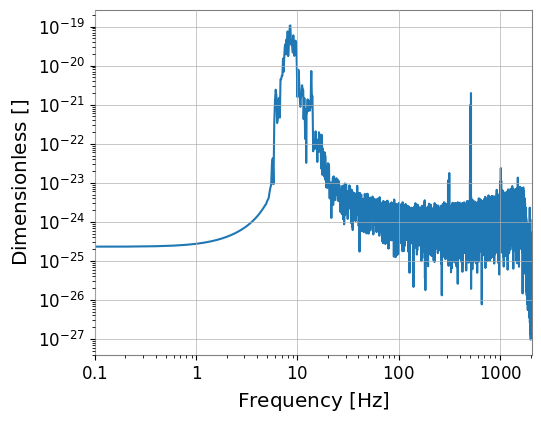

In [18]:
# Plotting the fourier transform using the mathematical and the defined method

fftamp_my = lwin_my.fft().abs()
fftamp = lwin.fft().abs()
plot = fftamp_my.plot(xscale="log", yscale="log")
plot = fftamp.plot(xscale="log", yscale="log")

Power Spectral Density

The fluctuations in the above plot at frequencies larger than 10 Hz seem completely random. This is indeed the intrinsic noise in the estimate of the spectral content of the signal from a single FFT. We can reduce these fluctuations by averaging many estimates of the signal FFT. But, being the FFT components complex quantities, what we really want to average are their squared moduli. This quantity is named Power Spectral Density (PSD), and what we have just described is Welch's estimation method. It is also convenient to express the result not as a power but as an amplitude, taking the square root of the above expression. The resulting quantity takes the name Amplitude Spectral Density (ASD) of the signal

<>:42: SyntaxWarning: invalid escape sequence '\s'
<>:42: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_24251/821059435.py:42: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('ASD [1/$\sqrt{\text{Hz}}$]')


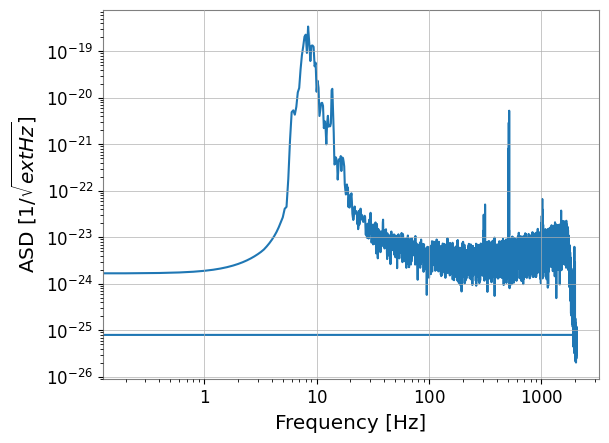

In [21]:
# Working of ASD

fftlength = 5
method = "median"

data = ldata.value
sample_rate = ldata.sample_rate.value
dt = ldata.dt
n_samples = len(data)

nperseg = int(fftlength * sample_rate) #no of samples
noverlap = nperseg // 2 #overlap

window = get_window('hann', nperseg)
segment_psds = []

# Iterate through the data with overlap to extract segments
# The step size is nperseg - noverlap
step = nperseg - noverlap
for i in range(0, n_samples - nperseg + 1, step):
    segment = data[i : i + nperseg]

    segment_windowed = segment * window #apply window
    segment_fft = np.fft.fft(segment_windowed) #compute fft
    segment_power_spectrum = np.abs(segment_fft)**2 #square mag
    segment_psds.append(segment_power_spectrum) #add to list

# Median Calculation
stacked_psds = np.stack(segment_psds, axis=-1) # Shape (nperseg//2 + 1, num_segments)
median_psd = np.median(stacked_psds, axis=-1) # Shape (nperseg//2 + 1,)

# Frequencies
frequencies = np.fft.fftfreq(nperseg, d=dt)
psd_manual_normalized = median_psd * (2.0 / (sample_rate * np.sum(window**2)))

# Compute the Amplitude Spectral Density (ASD)
asd_manual = np.sqrt(psd_manual_normalized)

# Plotting
plt.loglog(frequencies, asd_manual)
plt.xlabel('Frequency [Hz]')
plt.ylabel('ASD [1/$\sqrt{\text{Hz}}$]')
plt.show()

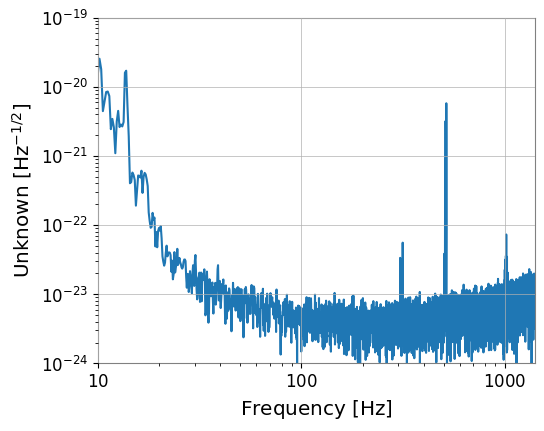

In [20]:
asd = ldata.asd(fftlength=5, method="median")
plot = asd.plot()
ax = plot.gca()
ax.set(xlim=(10, 1400), ylim=(1e-24, 1e-19))
plot
plot.show(warn=False)

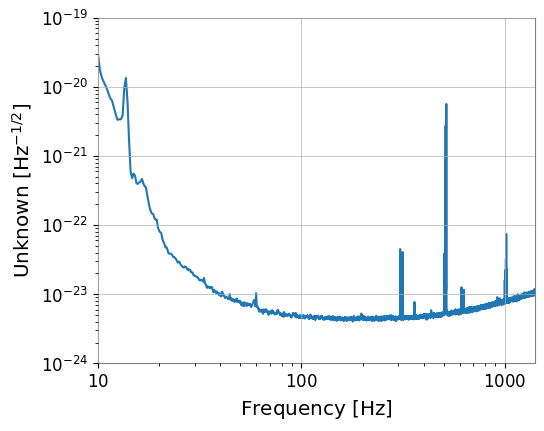

In [22]:
ldata2 = TimeSeries.fetch_open_data('L1', int(gps)-512, int(gps)+512, cache=True)
lasd2 = ldata2.asd(fftlength=4, method="median")
plot = lasd2.plot()
ax = plot.gca()
ax.set_xlim(10, 1400)
ax.set_ylim(1e-24, 1e-19)
plot.show(warn=False)

In [ ]:
import matplotlib.pyplot as plt
from gwpy.timeseries import TimeSeries

# Fetch data
ldata2 = TimeSeries.fetch_open_data('L1', int(gps)-512, int(gps)+512, cache=True)
lasd2 = ldata2.asd(fftlength=4, method="median")

vdata2 = TimeSeries.fetch_open_data('V1', int(gps)-512, int(gps)+512, cache=True)
vasd2 = vdata2.asd(fftlength=4, method="median")

hdata2 = TimeSeries.fetch_open_data('H1', int(gps)-512, int(gps)+512, cache=True)
hasd2 = hdata2.asd(fftlength=4, method="median")

# Create plot
fig, ax = plt.subplots()  # Better to explicitly create figure and axis

ax.loglog(lasd2.frequencies.value, lasd2.value, label='Livingston')  # loglog!
ax.loglog(vasd2.frequencies.value, vasd2.value, label='Virgo')
ax.loglog(hasd2.frequencies.value, hasd2.value, label='Hanford')

ax.legend()

ax.set_xlim(10, 1400)
ax.set_ylim(1e-24, 1e-20)

ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('ASD [$1/\sqrt{Hz}$]')

<>:27: SyntaxWarning: invalid escape sequence '\s'
<>:27: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_24251/4180058113.py:27: SyntaxWarning: invalid escape sequence '\s'
  ax.set_ylabel('ASD [$1/\sqrt{Hz}$]')
